<a href="https://colab.research.google.com/github/EstevahnAguilera/Data-Science-Projects/blob/main/Integrated_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Description
- Prepare a prototype of a machine learning model for Zyfra. The company develops efficiency solutions for heavy industry.
- The model should predict the amount of gold recovered from gold ore. You have the data on extraction and purification.
- The model will help to optimize the production and eliminate unprofitable parameters.

## Data Description
- **Technological process**
    - *Rougher feed* — raw material
    - *Rougher additions* (or *reagent additions*) — flotation reagents: *Xanthate, Sulphate, Depressant*
        - *Xanthate* — promoter or flotation activator;
        - *Sulphate* — sodium sulphide for this particular process;
        - *Depressant* — sodium silicate.
    - *Rougher process* — flotation
    - *Rougher tails* — product residues
    - *Float banks* — flotation unit
    - *Cleaner process* — purification
    - *Rougher Au* — rougher gold concentrate
    - *Final Au* — final gold concentrate
- **Parameters of stages**
    - *air amount — volume of air*
    - *fluid levels*
    - *feed size* — feed particle size
    - *feed rate*

## Getting Started
I will begin by setting up the environment.
### Importing Libraries
I need to import the necessary libraries.

In [ ]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, cross_val_predict

In [ ]:
# Importing the .csv files from local computer
from google.colab import files
uploaded_0 = files.upload() # gold_train
uploaded_1 = files.upload() # gold_test
uploaded_2 = files.upload() # gold_full

Saving gold_recovery_train.csv to gold_recovery_train.csv


Saving gold_recovery_test.csv to gold_recovery_test.csv


Saving gold_recovery_full.csv to gold_recovery_full.csv


In [ ]:
# Reading the datasets
gold_train = pd.read_csv('gold_recovery_train.csv')
gold_test = pd.read_csv('gold_recovery_test.csv')
gold_full = pd.read_csv('gold_recovery_full.csv')

## Prepare the Data

In [ ]:
# Analyzing the data
def analyze_data(dataframe_name, dataframe):
    print(f"Analyzing {dataframe_name}: \n")
    # Using .info() to check non-null count, column names, and dtype
    print(dataframe.info(), '\n')
    # Using .head() to analyze the meaning of the data
    print(dataframe.head(), '\n')

analyze_data('Train', gold_train)
analyze_data('Test', gold_test)
analyze_data('Full', gold_full)

Analyzing Train: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715

### After analyzing the data:
- Right off the bat, I can see that the date column's type needs to be changed from object to datetime.
- All three DataFrames have missing values so lets tackle that too.
- Let's also plot these DataFrames to see the distribution.

In [ ]:
# Changing the date column in all three dataframes to_datetime
# The train dataframe
gold_train['date'] = pd.to_datetime(gold_train['date'])

# The test dataframe
gold_test['date'] = pd.to_datetime(gold_test['date'])

# The full dataframe
gold_full['date'] = pd.to_datetime(gold_full['date'])

# Checking the datatypes to make sure they changed
print(gold_train['date'].dtype)
print(gold_test['date'].dtype)
print(gold_full['date'].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]


In [ ]:
# Looking at the number of missing values for each data set

# Gold Train
print(f"There are {gold_train.isna().sum().sum()} missing values for the training set.")

# Gold Test
print(f"There are {gold_test.isna().sum().sum()} missing values for the testing set.")

# Gold full
print(f"There are {gold_full.isna().sum().sum()} missing values for the full set.")

There are 30320 missing values for the training set.
There are 2360 missing values for the testing set.
There are 36587 missing values for the full set.


### Filling in missing values
- I will be filling in the missing values with the median value from the training set.
    - I will be filling it in with the median values as opposed to the mean values due to the fact that the mean value can be affected by any outliers which may throw off our model.
    - I will also be filling the rest of the dataframes with the median value of the training set due to the fact that in the real world, if we were to train prediction models, they wouldn't have the answers because its a prediction. With that being said, if I were to train the model on the test or the full dataframe, it would almost be as if I were to cheat.

In [ ]:
# Filling in the missing values with the median values of the training set
# Calculating the median values
median_value = gold_train.median()

# Filling in the median values
gold_train = gold_train.fillna(median_value)
gold_test = gold_test.fillna(median_value)
gold_full = gold_full.fillna(median_value)

# Checking if there is anymore missing values
print(f"There are {gold_train.isna().sum().sum()} missing values for the training set.")
print(f"There are {gold_test.isna().sum().sum()} missing values for the testing set.")
print(f"There are {gold_full.isna().sum().sum()} missing values for the full set.")

There are 0 missing values for the training set.
There are 0 missing values for the testing set.
There are 0 missing values for the full set.


### Distribution
I will be looking at the distribution of the recovery columns in the train set.

In [ ]:
# This should help me find all columns with 'recovery' in the name
recovery_columns = [col for col in gold_train.columns if 'recovery' in col.lower()]
print(recovery_columns)

['final.output.recovery', 'rougher.output.recovery']


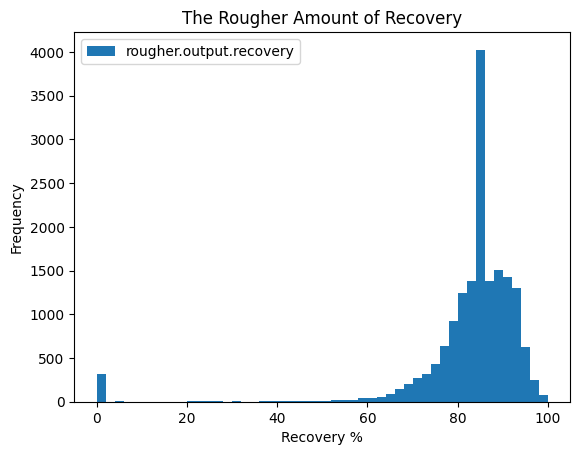

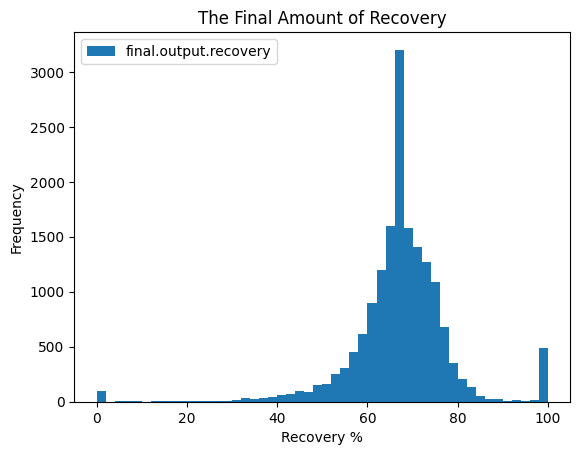

In [ ]:
# Plotting a histogram
gold_train[['rougher.output.recovery']].plot(kind = 'hist',
                                            xlabel = 'Recovery %',
                                            title = 'The Rougher Amount of Recovery',
                                            bins = 50
                                            )

gold_train[['final.output.recovery']].plot(kind = 'hist',
                                            xlabel = 'Recovery %',
                                            title = 'The Final Amount of Recovery',
                                            bins = 50
                                            )
plt.show()

The Rougher Amount of Recovery:
- The distribution is centered around 80-90%
- Most values appear to be in the 75-95% range
- This represents the initial floatation process recovery rate

The Final Amount of Recovery:
- The distribution is centered around 65-75%
- Most values appear to be in the 60-80% range
- This represents the overall process recovery rate

Conclusion:
- Rougher recovery measures how much gold is recovered from the raw ore in the intial flotation step
    - The rougher recovery is higher due to the fact that:
        - It only measures the first step
- Final recovery measures the overall efficiency of the entire process from start to finish
    - The final recovery is lower due to the fact that:
        - Some gold is lost during the cleaning and purification stages
        - It accounts for the losses throughout the process

## Recovery Calculations

In [ ]:
# Defining the valriables for the recovery calculations

# Extracting necessary columns
C = gold_train['rougher.output.concentrate_au']  # Concentrate gold content
F = gold_train['rougher.input.feed_au']          # Feed gold content
T = gold_train['rougher.output.tail_au']         # Tail gold content

# Calculating the recovery calculations
recovery_calc = ((C * (F - T)) / (F * (C - T))) * 100

# After calculating the Recovery_calc and running the MAE I got an error so I did the following steps
# Let's examine the calculated recovery values
print("Recovery calculation results:")
print(f"Shape: {recovery_calc.shape}")
print(f"NaN values: {recovery_calc.isna().sum()}")
print(f"Infinite values: {np.isinf(recovery_calc).sum()}")
print(f"Min value: {recovery_calc.min()}")
print(f"Max value: {recovery_calc.max()}")

# Create a mask to identify valid values (not NaN and not infinite)
valid_mask = ~(recovery_calc.isna() | np.isinf(recovery_calc))

# Filter both arrays to only include valid values
recovery_calc_clean = recovery_calc[valid_mask]
recovery_existing_clean = gold_train['rougher.output.recovery'][valid_mask]

# Now calculate the MAE
mae = mean_absolute_error(recovery_existing_clean, recovery_calc_clean)
print(f"MAE: {mae}")
print(f"Number of valid samples used: {len(recovery_calc_clean)}")

Recovery calculation results:
Shape: (16860,)
NaN values: 1115
Infinite values: 44
Min value: -inf
Max value: inf
MAE: 56.831082843744696
Number of valid samples used: 15701


In [ ]:
# Find features that are in training set but not in test set
train_features = set(gold_train.columns)
test_features = set(gold_test.columns)
missing_features = train_features - test_features

print(f"Number of features missing from test set: {len(missing_features)}")
print("\nMissing features:")
for feature in sorted(missing_features):
    print(f"- {feature}")

Number of features missing from test set: 34

Missing features:
- final.output.concentrate_ag
- final.output.concentrate_au
- final.output.concentrate_pb
- final.output.concentrate_sol
- final.output.recovery
- final.output.tail_ag
- final.output.tail_au
- final.output.tail_pb
- final.output.tail_sol
- primary_cleaner.output.concentrate_ag
- primary_cleaner.output.concentrate_au
- primary_cleaner.output.concentrate_pb
- primary_cleaner.output.concentrate_sol
- primary_cleaner.output.tail_ag
- primary_cleaner.output.tail_au
- primary_cleaner.output.tail_pb
- primary_cleaner.output.tail_sol
- rougher.calculation.au_pb_ratio
- rougher.calculation.floatbank10_sulfate_to_au_feed
- rougher.calculation.floatbank11_sulfate_to_au_feed
- rougher.calculation.sulfate_to_au_concentrate
- rougher.output.concentrate_ag
- rougher.output.concentrate_au
- rougher.output.concentrate_pb
- rougher.output.concentrate_sol
- rougher.output.recovery
- rougher.output.tail_ag
- rougher.output.tail_au
- rougher.o

## Missing Features

In [ ]:
# Let's categorize the missing features
missing_features_list = sorted(list(missing_features))

# Group by process stage
rougher_features = [f for f in missing_features_list if 'rougher' in f]
primary_features = [f for f in missing_features_list if 'primary' in f]
secondary_features = [f for f in missing_features_list if 'secondary' in f]
final_features = [f for f in missing_features_list if 'final' in f]

print("Missing features by process stage:")
print(f"Rougher stage: {len(rougher_features)} features")
print(f"Primary stage: {len(primary_features)} features")
print(f"Secondary stage: {len(secondary_features)} features")
print(f"Final stage: {len(final_features)} features")

Missing features by process stage:
Rougher stage: 13 features
Primary stage: 8 features
Secondary stage: 4 features
Final stage: 9 features


In [ ]:
# Let's analyze by feature type (output vs calculation vs other)
output_features = [f for f in missing_features_list if '.output.' in f]
calculation_features = [f for f in missing_features_list if '.calculation.' in f]

print("Missing features by type:")
print(f"Output measurements: {len(output_features)} features")
print(f"Calculation features: {len(calculation_features)} features")

print("\nOutput features:")
for feature in output_features:
    print(f"- {feature}")

print("\nCalculation features:")
for feature in calculation_features:
    print(f"- {feature}")

Missing features by type:
Output measurements: 30 features
Calculation features: 4 features

Output features:
- final.output.concentrate_ag
- final.output.concentrate_au
- final.output.concentrate_pb
- final.output.concentrate_sol
- final.output.recovery
- final.output.tail_ag
- final.output.tail_au
- final.output.tail_pb
- final.output.tail_sol
- primary_cleaner.output.concentrate_ag
- primary_cleaner.output.concentrate_au
- primary_cleaner.output.concentrate_pb
- primary_cleaner.output.concentrate_sol
- primary_cleaner.output.tail_ag
- primary_cleaner.output.tail_au
- primary_cleaner.output.tail_pb
- primary_cleaner.output.tail_sol
- rougher.output.concentrate_ag
- rougher.output.concentrate_au
- rougher.output.concentrate_pb
- rougher.output.concentrate_sol
- rougher.output.recovery
- rougher.output.tail_ag
- rougher.output.tail_au
- rougher.output.tail_pb
- rougher.output.tail_sol
- secondary_cleaner.output.tail_ag
- secondary_cleaner.output.tail_au
- secondary_cleaner.output.tail_

Why are these features missing?
- Output measurements are only available after the flotation process completes
- Calculation features depend on output measurements, so they're also unavailable until after the process
- Predictions need to be made while the process is still running or before it starts

What this means for our model:
- You can measure input parameters (feed rates, reagent amounts, etc.) in real-time
- You cannot measure concentrate and tail outputs until the process finishes
- Your model must predict recovery using only the available input features

### Perform data preprocessing

In [ ]:
# Create training dataset with only features available in test set
available_features = list(test_features)
gold_train_clean = gold_train[available_features].copy()

print(f"Original training set shape: {gold_train.shape}")
print(f"Cleaned training set shape: {gold_train_clean.shape}")
print(f"Test set shape: {gold_test.shape}")

Original training set shape: (16860, 87)
Cleaned training set shape: (16860, 53)
Test set shape: (5856, 53)


In [ ]:
# Extract target variables before cleaning
targets = gold_train[['rougher.output.recovery', 'final.output.recovery']].copy()
print(f"Target variables shape: {targets.shape}")
print(f"Missing values in targets: {targets.isna().sum()}")

Target variables shape: (16860, 2)
Missing values in targets: rougher.output.recovery    0
final.output.recovery      0
dtype: int64


## Analyze the Data

### First we will look at how the metals change during each purification stage!

In [ ]:
# Looking at how the average concentration of metals change depending on the purification stage
concentration_stages = {
    'Stage' : ['Feed', 'Rougher', 'Primary', 'Final'],
    'Au' : [
        gold_train['rougher.input.feed_au'].mean(),
        gold_train['rougher.output.concentrate_au'].mean(),
        gold_train['primary_cleaner.output.concentrate_au'].mean(),
        gold_train['final.output.concentrate_au'].mean()
    ],
    'Ag' : [
        gold_train['rougher.input.feed_ag'].mean(),
        gold_train['rougher.output.concentrate_ag'].mean(),
        gold_train['primary_cleaner.output.concentrate_ag'].mean(),
        gold_train['final.output.concentrate_ag'].mean()
    ],
    'Pb' : [
        gold_train['rougher.input.feed_pb'].mean(),
        gold_train['rougher.output.concentrate_pb'].mean(),
        gold_train['primary_cleaner.output.concentrate_pb'].mean(),
        gold_train['final.output.concentrate_pb'].mean()
    ],
}

concentration_df = pd.DataFrame(concentration_stages)
print(concentration_df)

     Stage         Au         Ag        Pb
0     Feed   7.172060   7.832862  3.219987
1  Rougher  17.412450  10.584752  6.883743
2  Primary  29.181542   7.425434  8.641498
3    Final  39.488406   4.717558  9.117624


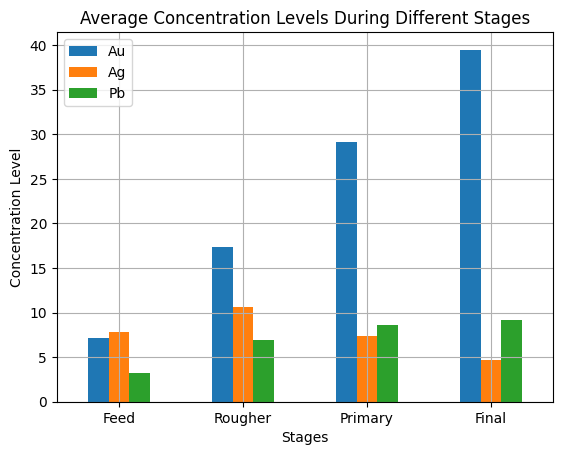

In [ ]:
# Plotting a barchart to show the difference in concentration

concentration_plot = concentration_df.plot(kind = 'bar',
                     title = 'Average Concentration Levels During Different Stages',
                     ylabel = 'Concentration Level' ,
                     xlabel = 'Stages',
                     grid = True,
                     rot = 0)
# Setting the xlabel as the different stages
concentration_plot.set_xticklabels(concentration_df['Stage'])
plt.show()

We can clearly see how the average concentration levels change during each process.
- Au:
    - We can see that the concentration levels grow linearly throughout each stage.
- Ag:
    - We can see that the concentration levels rise from the feed stage to the rougher stage, but then we see a fall in concentration after the primary and final stages.
- Pb:
    - We can see a linear growth during each stage, but it is not a dramatic growth compared to gold.

### Let's compare the feed particle sizes between the training and the test set.

In [ ]:
# Comparing the basic statistics of feed sizes for both DataFrame's
print("Feed Size Statistics Comparison:")
print("\nTraining Set:")
print(gold_train['rougher.input.feed_size'].describe())
print("\nTest Set:")
print(gold_test['rougher.input.feed_size'].describe())

Feed Size Statistics Comparison:

Training Set:
count    16860.000000
mean        58.563359
std         23.635551
min          9.659576
25%         47.597875
50%         54.104257
75%         64.587648
max        484.967466
Name: rougher.input.feed_size, dtype: float64

Test Set:
count    5856.000000
mean       55.930648
std        22.681798
min         0.046369
25%        43.898467
50%        50.109024
75%        61.608216
max       477.445473
Name: rougher.input.feed_size, dtype: float64


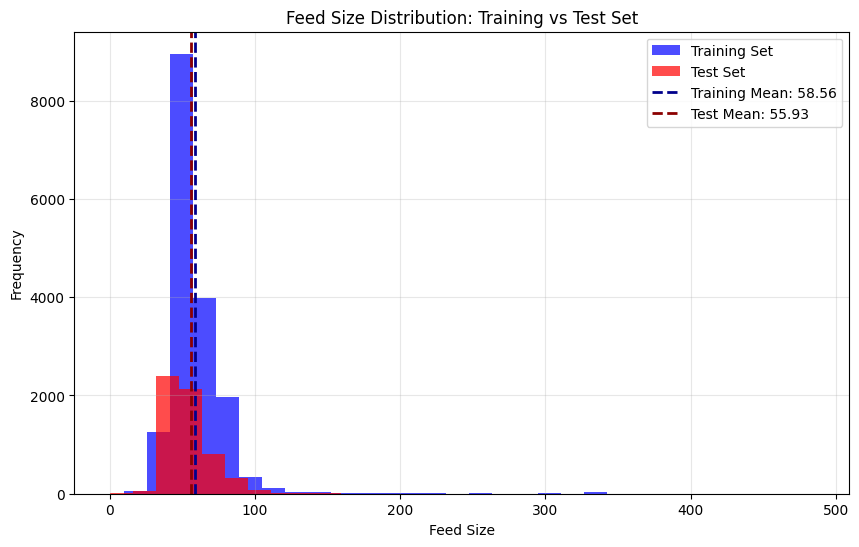

In [ ]:
# Plotting the difference between the two
plt.figure(figsize=(10, 6))
plt.hist(gold_train['rougher.input.feed_size'].dropna(),
         bins=30, alpha=0.7, label='Training Set', color='blue')
plt.hist(gold_test['rougher.input.feed_size'].dropna(),
         bins=30, alpha=0.7, label='Test Set', color='red')

# Calculate the means
train_mean = gold_train['rougher.input.feed_size'].mean()
test_mean = gold_test['rougher.input.feed_size'].mean()

# Add vertical lines for the means
plt.axvline(train_mean, color='darkblue', linestyle='--', linewidth=2,
           label=f'Training Mean: {train_mean:.2f}')
plt.axvline(test_mean, color='darkred', linestyle='--', linewidth=2,
           label=f'Test Mean: {test_mean:.2f}')

plt.xlabel('Feed Size')
plt.ylabel('Frequency')
plt.title('Feed Size Distribution: Training vs Test Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

After comparing the two Feed Sizes:
- We can see that the distribution is fairly the same.
- We can also see that the mean lines aren't that far off which.

With that being said, the distribution and the mean of the two sets are fairly the same which means that it won't affect our models prediction to a point where it is off by a lot.

### Now, let's consider the total concentrations of all substances at different stages:
- Raw feed
- Rougher Concentration
- Final Concentration

Questions to consider:
- Do you notice any abnormal values in the total distribution?
- If you do, is it worth removing such values from both samples?

Describe the findings afterwards.

In [ ]:
# Summing up the total concentrations of all substances at different stages:
total_raw_feed = (gold_train['rougher.input.feed_au'] +
                  gold_train['rougher.input.feed_ag'] +
                  gold_train['rougher.input.feed_pb'] +
                  gold_train['rougher.input.feed_sol'])

total_rougher_concentrate = (gold_train['rougher.output.concentrate_au'] +
                            gold_train['rougher.output.concentrate_ag'] +
                            gold_train['rougher.output.concentrate_pb'] +
                            gold_train['rougher.output.concentrate_sol'])

total_final_concentrate = (gold_train['final.output.concentrate_au'] +
                          gold_train['final.output.concentrate_ag'] +
                          gold_train['final.output.concentrate_pb'] +
                          gold_train['final.output.concentrate_sol'])

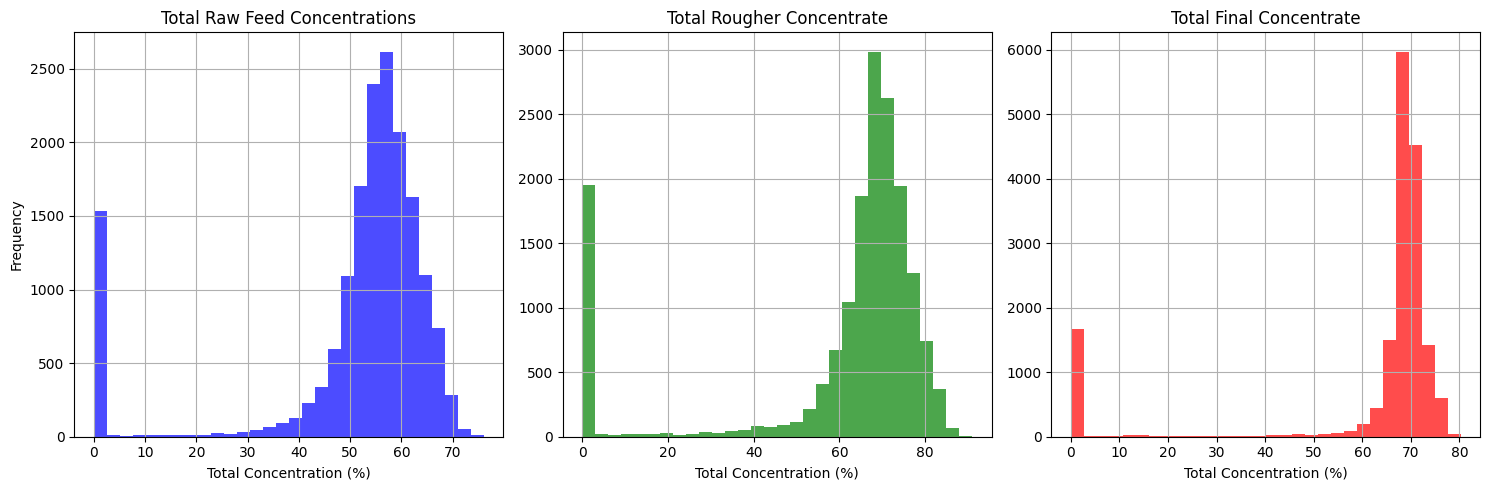

In [ ]:
# Plotting a histogram for all stages

# Creating subplots to compare all three stages
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot all three histograms:
# Raw feed
total_raw_feed.hist(bins=30, ax=axes[0], alpha=0.7, color='blue')
axes[0].set_title('Total Raw Feed Concentrations')
axes[0].set_xlabel('Total Concentration (%)')
axes[0].set_ylabel('Frequency')

# Rougher concentrate
total_rougher_concentrate.hist(bins=30, ax=axes[1], alpha=0.7, color='green')
axes[1].set_title('Total Rougher Concentrate')
axes[1].set_xlabel('Total Concentration (%)')

# Final concentrate
total_final_concentrate.hist(bins=30, ax=axes[2], alpha=0.7, color='red')
axes[2].set_title('Total Final Concentrate')
axes[2].set_xlabel('Total Concentration (%)')

plt.tight_layout()
plt.show()

After looking at the histograms, we can see there is an abnormal amount of 0's.
I will look into this further.

In [ ]:
# lets look at the statistics for each total
print("Raw Feed Total Concentration Statistics:")
print(total_raw_feed.describe())

print("\nRougher Concentrate Total Statistics:")
print(total_rougher_concentrate.describe())

print("\nFinal Concentrate Total Statistics:")
print(total_final_concentrate.describe())

Raw Feed Total Concentration Statistics:
count    16860.000000
mean        50.925954
std         17.678604
min          0.000000
25%         50.610634
50%         55.810185
75%         60.275354
max         76.024095
dtype: float64

Rougher Concentrate Total Statistics:
count    16860.000000
mean        60.302695
std         23.679468
min          0.000000
25%         61.679236
50%         68.332115
75%         73.017601
max         90.964431
dtype: float64

Final Concentrate Total Statistics:
count    16860.000000
mean        61.630331
std         21.373253
min          0.000000
25%         66.780933
50%         68.828223
75%         70.704257
max         80.210644
dtype: float64


In [ ]:
# Checking for physically impossible values (>100%) and suspicious zeros
print("Checking for physically impossible values:")
print(f"Raw feed >100%: {(total_raw_feed > 100).sum()}")
print(f"Rougher concentrate >100%: {(total_rougher_concentrate > 100).sum()}")
print(f"Final concentrate >100%: {(total_final_concentrate > 100).sum()}")

print("\nChecking for zero values:")
print(f"Raw feed = 0: {(total_raw_feed == 0).sum()}")
print(f"Rougher concentrate = 0: {(total_rougher_concentrate == 0).sum()}")
print(f"Final concentrate = 0: {(total_final_concentrate == 0).sum()}")

Checking for physically impossible values:
Raw feed >100%: 0
Rougher concentrate >100%: 0
Final concentrate >100%: 0

Checking for zero values:
Raw feed = 0: 1159
Rougher concentrate = 0: 1493
Final concentrate = 0: 1263


In [ ]:
# Check if zero values occur at the same time across stages
zero_mask_raw = (total_raw_feed == 0)
zero_mask_rougher = (total_rougher_concentrate == 0)
zero_mask_final = (total_final_concentrate == 0)

print("Overlap analysis of zero values:")
print(f"Raw and Rougher both zero: {(zero_mask_raw & zero_mask_rougher).sum()}")
print(f"Raw and Final both zero: {(zero_mask_raw & zero_mask_final).sum()}")
print(f"Rougher and Final both zero: {(zero_mask_rougher & zero_mask_final).sum()}")
print(f"All three stages zero: {(zero_mask_raw & zero_mask_rougher & zero_mask_final).sum()}")

Overlap analysis of zero values:
Raw and Rougher both zero: 1115
Raw and Final both zero: 1060
Rougher and Final both zero: 1111
All three stages zero: 1053


We can see that there is overlapping of 0's for the same row. Let's look into it further.

In [ ]:
# Finding timestamps when all stages are zero
all_zero_mask = (zero_mask_raw & zero_mask_rougher & zero_mask_final)
zero_timestamps = gold_train[all_zero_mask]['date']

# Looking at the time patterns
print("Sample of timestamps when all stages are zero:")
print(zero_timestamps.head(10))

Sample of timestamps when all stages are zero:
99    2016-01-19 03:00:00
100   2016-01-19 04:00:00
101   2016-01-19 05:00:00
102   2016-01-19 06:00:00
103   2016-01-19 07:00:00
104   2016-01-19 08:00:00
105   2016-01-19 09:00:00
106   2016-01-19 10:00:00
107   2016-01-19 11:00:00
108   2016-01-19 12:00:00
Name: date, dtype: datetime64[ns]


Looking at the time stamp of when all stages are zero, we can see that it happened on the same exact day for consecutive hours between 3 - 12.

It is important to note that there could have been equipment shutdown, maintenance, or no material being processed.

It would be essential to remove this along with any rows where the feed is 0 as this isn't necessary for our model. If there isn't anything being processed, then there is no need to hold onto that unecessary data.

In [ ]:
# Removing the rows that have zero for all values

def remove_zero_feed_rows(dataframe):
    """Remove rows where total input feed equals zero"""
    total_feed = (dataframe['rougher.input.feed_ag'] +
                  dataframe['rougher.input.feed_pb'] +
                  dataframe['rougher.input.feed_sol'] +
                  dataframe['rougher.input.feed_au'])

    # Keep only rows where total feed > 0
    return dataframe[total_feed > 0].copy()

In [ ]:
# Removing the rows for both the test and training set
print('Gold Train size before: ', gold_train.shape)
print('Gold Test size before: ', gold_test.shape)

gold_train = remove_zero_feed_rows(gold_train)
gold_test = remove_zero_feed_rows(gold_test)

print('Gold Train size after: ', gold_train.shape)
print('Gold Test size after: ', gold_test.shape)

Gold Train size before:  (16860, 87)
Gold Test size before:  (5856, 53)
Gold Train size after:  (15701, 87)
Gold Test size after:  (5487, 53)


## Building the Model

### Calculating the sMAPE value

In [ ]:
# First we will need to create a function that will calculate the
# sMAPE value for one target at a time

def smape_single(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    numerator = np.abs(y_true - y_pred)

    # handle if denominator is 0
    nonzero_denom_mask = denominator != 0

    # handling if y_true and y_predict = 0
    if len(numerator[nonzero_denom_mask]) == 0:
        return 0.0
    else:
        smape_value = np.mean(numerator[nonzero_denom_mask] / denominator[nonzero_denom_mask]) *  100

    return smape_value

# Testing
print(smape_single([1, 2, 3], [1, 2, 4]) )
print(smape_single([0, 0], [0, 0]))

9.523809523809524
0.0


### Calculating the final sMAPE value

In [ ]:
# Final sMAPE function

def final_smape(first_true, first_pred, second_true, second_pred):
    return 0.25 * smape_single(first_true, first_pred) + 0.75 * smape_single(second_true, second_pred)

# Testing
final_smape([80, 90], [80, 85], [70, 75], [70, 80])

np.float64(3.1336405529953915)

### Features and Target
The features should only be the columns that are in the test set so we need to
drop all of the other columns.

The target variables are:
- 'rougher.output.recovery'
- 'final.output.recovery'

In [ ]:
# Features and Target

# features
    # get golumns that exist in both datasets
common_columns = list(set(gold_train.columns) & set(gold_test.columns))
print(f"Number of common columns: {len(common_columns)}")

    # removing 'date' from features as its not necessary
feature_columns = [col for col in common_columns if col != 'date']
x = gold_train[feature_columns]


# target
y_rougher = gold_train['rougher.output.recovery']
y_final = gold_train['final.output.recovery']

Number of common columns: 53


In [ ]:
# Set up KFold
kf = KFold(n_splits = 5, random_state = 12345, shuffle = True)

Training different models!

In [ ]:
# Dictionary to store all models that I will be testing
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree Regressor' : DecisionTreeRegressor(random_state = 12345),
    'Random Forest Regressor' : RandomForestRegressor(n_estimators = 100, random_state = 12345)
}

# Storing results for comparison
model_results = {}

print("Testing different models with cross-validation...")
print('-' * 50)

for model_name, model in models.items():
    print(f"Training {model_name}...")

    # creating separate models for rougher and final
    rougher_model = model
    final_model = type(model)(**model.get_params()) # this creates a copy with the same params

    # Cross validation predictions
    rougher_pred = cross_val_predict(rougher_model, x, y_rougher, cv = kf)
    final_pred = cross_val_predict(final_model, x, y_final, cv = kf)

    # Calculating the sMAPE scores
    score = final_smape(y_rougher, rougher_pred, y_final, final_pred)

    # Store the results
    model_results[model_name] = score

    print(f"{model_name} sMAPE: {score:.4f} \n")

# Finding the best model
best_model_name = min(model_results, key = model_results.get)
best_score = model_results[best_model_name]

# Results
print("RESULTS SUMMARY:")
print('-' * 50)

print(f"\nBest model: {best_model_name} (sMAPE: {best_score:.4f})")

Testing different models with cross-validation...
--------------------------------------------------
Training Linear Regression...
Linear Regression sMAPE: 10.3089 

Training Decision Tree Regressor...
Decision Tree Regressor sMAPE: 9.8330 

Training Random Forest Regressor...
Random Forest Regressor sMAPE: 7.6198 

RESULTS SUMMARY:
--------------------------------------------------

Best model: Random Forest Regressor (sMAPE: 7.6198)


Right off the bat, we can see that the Random Forest Regressor model has the best sMAPE score. With that being said, I will be using that model for my final test.

### Final test with the Test set

In [ ]:
# Rougher & Final model
last_rougher_model = RandomForestRegressor(n_estimators=100, random_state=12345)
last_final_model = RandomForestRegressor(n_estimators=100, random_state=12345)

# Training the model
last_rougher_model.fit(x, y_rougher)
last_final_model.fit(x, y_final)

# Prepping the test set
x_test = gold_test[feature_columns]

# Making predictions on the test set
rougher_pred_test = last_rougher_model.predict(x_test)
final_pred_test = last_final_model.predict(x_test)

# Since we know that the sMAPE score is 7.6137 and we can't run sMAPE on our test set simply
# because of the size of our test set compared to our training set, below is some predictions
print("FINAL MODEL PREDICTIONS ON TEST SET")
print(f"Test set size: {len(rougher_pred_test)} samples \n")
print("Sample of predictions:")
print("Rougher Recovery | Final Recovery")
print("-" * 35)
for i in range(10):  # Show first 10 predictions
    print(f"{rougher_pred_test[i]:13.4f} | {final_pred_test[i]:12.4f}")
print("...")

FINAL MODEL PREDICTIONS ON TEST SET
Test set size: 5487 samples 

Sample of predictions:
Rougher Recovery | Final Recovery
-----------------------------------
      89.0857 |      69.2420
      87.0544 |      69.3114
      85.6114 |      69.5548
      87.6302 |      69.5712
      87.1497 |      67.9774
      85.5625 |      68.7105
      80.7539 |      64.1780
      78.1578 |      64.1198
      76.0908 |      64.8085
      80.2152 |      63.7526
...


Summary:
- Random Forest outperformed Linear Regression and Decision Tree.
- After trying multiple parameters (such as adding depth to the trees, and changing the n_estimators), I found that just n_estimators = 100 was the best (7.6137).
- Therefore, I went ahead and ran the same model on our test set.
- I wasn't able to run sMAPE on the test set due to the fact that the training set has much more data compared to the test set.